In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta, cauchy, halfcauchy
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Этап 1


ticker = 'AAPL'
start_date = '2024-01-01'
end_date = '2026-07-15'

data = yf.download(ticker, start=start_date, end=end_date)
prices = data['Close'].copy()
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

mean_returns = log_returns.mean()
centered_returns = log_returns - mean_returns

y_all = centered_returns.values.astype(np.float64)

dates_all = centered_returns.index

train_mask = dates_all < pd.Timestamp('2026-07-01')
test_mask = dates_all >= pd.Timestamp('2026-07-01')

y_train = y_all[train_mask]
y_test = y_all[test_mask]

dates_train = dates_all[train_mask]
dates_test = dates_all[test_mask]

print(f"Обучающая выборка: {len(y_train)} дней ({dates_train[0].date()} - {dates_train[-1].date()})")
print(f"Тестовая выборка: {len(y_test)} дней ({dates_test[0].date()} - {dates_test[-1].date()})")
print(f"Всего: {len(y_all)} дней")

if len(y_test) == 0:
    print("\nВНИМАНИЕ: Нет данных для теста после 30 июня 2025!")
    print("Попробуйте расширить end_date или изменить дату разделения.")

[*********************100%***********************]  1 of 1 completed

Обучающая выборка: 624 дней (2024-01-03 - 2026-06-30)
Тестовая выборка: 9 дней (2026-07-01 - 2026-07-14)
Всего: 633 дней


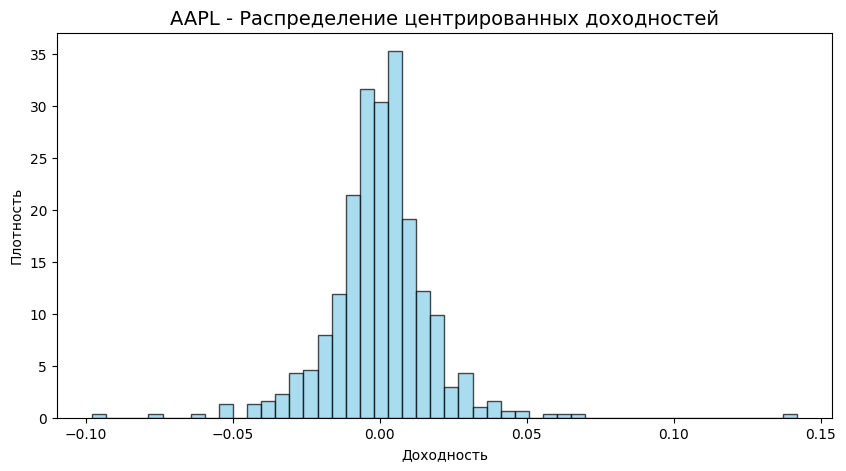

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(y_all, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f"{ticker} - Распределение центрированных доходностей", fontsize=14)
plt.xlabel("Доходность")
plt.ylabel("Плотность")
plt.grid(True, alpha=0)

In [5]:
#Этап 2

class SV_MCMC:

  def __init__(self, y, n_iter = 10000, n_burnin = 5000):
    self.y = y
    self.T = len(y)
    self.n_iter = n_iter
    self.n_burnin = n_burnin

    self.mu = -7.5
    self.phi = 0.97
    self.sigma_eta = 0.15

    self.h = np.zeros(self.T)
    self._initialize_h()

    self.samples_mu = []
    self.samples_phi = []
    self.samples_sigma_eta = []
    self.samples_h = []

    self.mh_step = 0.5

    self.accept_count = 0
    self.accept_total = 0
    self.mh_step_sigma = 0.05
    self.accept_sigma_count = 0
    self.accept_sigma_total = 0

  def _initialize_h(self):
    log_y2 = np.log(self.y ** 2 + 1e-8)
    self.h = uniform_filter1d(log_y2, size = 5, mode = 'nearest')
    self.h = self.h - self.h.mean() + self.mu

  def _sample_h_single(self, t):
    h_curr = self.h[t]
    h_prop = h_curr + np.random.normal(0, 0.2)

    log_like_curr = 0
    log_like_prop = 0

    log_like_curr += -0.5 * np.log(2 * np.pi) - 0.5 * h_curr - 0.5 * (self.y[t] ** 2 / np.exp(h_curr))
    log_like_prop += -0.5 * np.log(2 * np.pi) - 0.5 * h_prop - 0.5 * (self.y[t] ** 2 / np.exp(h_prop))

    if t > 0:
      mean_curr = self.mu + self.phi * (self.h[t-1] - self.mu)
      mean_prop = self.mu + self.phi * (self.h[t-1] - self.mu)
      log_like_curr += -0.5 * np.log(2 * np.pi) - 0.5 * np.log(self.sigma_eta ** 2) - 0.5 * ((h_curr - mean_curr) ** 2 / self.sigma_eta ** 2)
      log_like_prop += -0.5 * np.log(2 * np.pi) - 0.5 * np.log(self.sigma_eta ** 2) - 0.5 * ((h_prop - mean_prop) ** 2 / self.sigma_eta ** 2)

    if t < self.T - 1:
      mean_curr = self.mu + self.phi * (h_curr - self.mu)
      mean_prop = self.mu + self.phi * (h_prop - self.mu)
      log_like_curr += -0.5 * np.log(2 * np.pi) - 0.5 * np.log(self.sigma_eta ** 2) - 0.5 * ((self.h[t+1] - mean_curr) ** 2 / self.sigma_eta ** 2)
      log_like_prop += -0.5 * np.log(2 * np.pi) - 0.5 * np.log(self.sigma_eta ** 2) - 0.5 * ((self.h[t+1] - mean_prop) ** 2 / self.sigma_eta ** 2)


    if t == 0:
      stationary_var = self.sigma_eta ** 2 / (1 - self.phi ** 2)
      stationary_std = np.sqrt(stationary_var)
      log_prior_curr = norm.logpdf(h_curr, loc = self.mu, scale = stationary_std)
      log_prior_prop = norm.logpdf(h_prop, loc = self.mu, scale = stationary_std)
      log_like_curr += log_prior_curr
      log_like_prop += log_prior_prop


    log_ratio = log_like_prop - log_like_curr

    if np.log(np.random.rand()) < log_ratio:
      self.h[t] = h_prop

  def _sample_h_all(self):
    for t in range(self.T):
      self._sample_h_single(t)


  def _sample_mu(self):
    prior_precision = 1.0 / 100.0

    sum_weighted = 0.0
    sum_precision = 0.0

    for t in range(1, self.T):
      precision = 1 / (self.sigma_eta ** 2)
      sum_precision += precision * (1 - self.phi) ** 2
      sum_weighted += precision * (1 - self.phi) * (self.h[t] - self.phi * self.h[t-1])

    posterior_precision = prior_precision + sum_precision

    if posterior_precision > 0:
      posterior_mean = sum_weighted / posterior_precision
    else:
      posterior_mean = 0

    self.mu = np.random.normal(posterior_mean, np.sqrt(1 / posterior_precision))


  def _sample_sigma_eta(self):

    sigma_curr = self.sigma_eta
    log_sigma_curr = np.log(sigma_curr)
    log_sigma_prop = log_sigma_curr + np.random.normal(0, self.mh_step_sigma)
    sigma_prop = np.exp(log_sigma_prop)

    def log_posterior(sigma):
      if sigma <= 0:
        return -np.inf

      log_like = 0.0
      for t in range(1, self.T):
        mean = self.mu + self.phi * (self.h[t-1] - self.mu)
        log_like += -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * ((self.h[t] - mean) / sigma) ** 2

      log_prior = halfcauchy.logpdf(sigma, scale = 0.1)
      stationary_var = sigma ** 2 / (1 - self.phi ** 2)

      if stationary_var <= 0:
        return - np.inf

      stationary_std = np.sqrt(stationary_var)
      log_prior += norm.logpdf(self.h[0], loc = self.mu, scale = stationary_std)

      return log_like + log_prior

    log_ratio = log_posterior(sigma_prop) - log_posterior(sigma_curr) + np.log(sigma_prop/sigma_curr)

    self.accept_sigma_total += 1
    if np.log(np.random.rand()) < log_ratio:
      self.sigma_eta = sigma_prop
      self.accept_sigma_count += 1


  def _sample_phi_metropolis(self):

    phi_curr = self.phi
    epsilon = 1e-6
    phi_clipped = np.clip(phi_curr, epsilon, 1 - epsilon)
    psi_curr = np.log(phi_clipped / (1 - phi_clipped))
    psi_prop = psi_curr + np.random.normal(0, self.mh_step)
    phi_prop = 1 / (1 + np.exp(- psi_prop))

    def log_posterior_phi(phi_val):
      if phi_val < 0 or phi_val > 1:
        return -np.inf

      h_centered = self.h - self.mu
      diff = h_centered[1:] - phi_val * h_centered[:-1]
      log_like = -0.5 * (self.T - 1) * np.log(2 * np.pi)
      log_like -= 0.5 * (self.T - 1) * np.log(self.sigma_eta ** 2)
      log_like -= 0.5 * np.sum(diff ** 2) / (self.sigma_eta ** 2 + 1e-8)

      log_prior = beta.logpdf(phi_val, 20, 1.5)

      stationary_var = self.sigma_eta ** 2 / (1 - phi_val ** 2 + 1e-8)
      stationary_std = np.sqrt(stationary_var)
      log_prior += norm.logpdf(self.h[0], loc = self.mu, scale = stationary_std)

      return log_like + log_prior

    log_posterior_psi_curr = log_posterior_phi(phi_clipped) + np.log(phi_clipped * (1 - phi_clipped))
    log_posterior_psi_prop = log_posterior_phi(phi_prop) + np.log(phi_prop * (1 - phi_prop))

    log_ratio = log_posterior_psi_prop - log_posterior_psi_curr

    self.accept_total += 1

    if np.log(np.random.rand()) < log_ratio:
      self.phi = phi_prop
      self.accept_count += 1

  def run(self):

    print(f'запуск MCMC на {self.n_iter} итераций')
    print(f'Burn-in на {self.n_burnin} итераций')
    pbar = tqdm(range(self.n_iter))

    for iteration in pbar:
      self._sample_h_all()
      self._sample_mu()
      self._sample_sigma_eta()
      self._sample_phi_metropolis()

      if iteration >= self.n_burnin:
        self.samples_mu.append(self.mu.item() if hasattr(self.mu, 'item') else self.mu)
        self.samples_phi.append(self.phi.item() if hasattr(self.phi, 'item') else self.phi)
        self.samples_sigma_eta.append(self.sigma_eta.item() if hasattr(self.sigma_eta, 'item') else self.sigma_eta)
        self.samples_h.append(self.h.copy())

      if iteration % 100 == 0:
        mu_val = self.mu.item() if hasattr(self.mu, 'item') else self.mu
        phi_val = self.phi.item() if hasattr(self.phi, 'item') else self.phi
        sigma_val = self.sigma_eta.item() if hasattr(self.sigma_eta, 'item') else self.sigma_eta
        pbar.set_postfix({
            'mu': f'{mu_val:.3f}',
            'phi': f'{phi_val:.3f}',
            'sigma': f'{sigma_val:.3f}',
            'acc': f'{self.accept_count / (self.accept_total + 1e-6):.2f}'
        })

    pbar.close()

    accept_rate = self.accept_count / self.accept_total if self.accept_total > 0 else 0
    print(f'процентр принятий для phi: {accept_rate:.2%}')

    self.samples_mu = np.array(self.samples_mu)
    self.samples_phi = np.array(self.samples_phi)
    self.samples_sigma_eta = np.array(self.samples_sigma_eta)
    self.samples_h = np.array(self.samples_h)

    print(f'Сохранено сэмплов: {len(self.samples_mu)}')

  def get_posterior_means(self):

    return {
        'mu': self.samples_mu.mean(),
        'phi': self.samples_phi.mean(),
        'sigma_eta': self.samples_sigma_eta.mean()
    }

  def get_posterior_intervals(self, alpha = 0.05):

    if len(self.samples_mu) == 0:
      return {
          'mu': (np.nan, np.nan),
          'phi': (np.nan, np.nan),
          'sigma_eta': (np.nan, np.nan)
      }

    return {
        'mu': (np.percentile(self.samples_mu, 100 * alpha / 2),
               np.percentile(self.samples_mu, 100 * (1 - alpha / 2))),
        'phi': (np.percentile(self.samples_phi, 100 * alpha / 2),
                np.percentile(self.samples_phi, 100 * (1 - alpha / 2))),
        'sigma_eta': (np.percentile(self.samples_sigma_eta, 100 * alpha / 2),
                      np.percentile(self.samples_sigma_eta, 100 * (1 - alpha / 2)))
    }


  def get_last_h(self):

    if len(self.samples_mu) == 0:
      return {
          'mu': (np.nan, np.nan),
          'phi': (np.nan, np.nan),
          'sigma_eta': (np.nan, np.nan)
      }

    last_h_samples = self.samples_h[:, -1]
    return {
        'mean': last_h_samples.mean(),
        'std': last_h_samples.std(),
        'percentiles': (np.percentile(last_h_samples, 2.5),
                        np.percentile(last_h_samples, 97.5))
    }

In [6]:
n_iter = 10000
n_burnin = 5000

mcmc = SV_MCMC(y_train, n_iter=n_iter, n_burnin=n_burnin)
mcmc.run()

mu_samples = np.array(mcmc.samples_mu).flatten()
phi_samples = np.array(mcmc.samples_phi).flatten()
sigma_eta_samples = np.array(mcmc.samples_sigma_eta).flatten()
h_samples = np.array(mcmc.samples_h)  # форма: (n_samples, T_train)

print(f"\nСохранено сэмплов: {len(mu_samples)}")
print(f"Размер h_samples: {h_samples.shape}")

print("\nАпостериорные средние (обучающая выборка):")
print(f"μ = {mu_samples.mean():.4f}")
print(f"φ = {phi_samples.mean():.4f}")
print(f"σ_η = {sigma_eta_samples.mean():.4f}")

запуск MCMC на 10000 итераций
Burn-in на 5000 итераций


100%|██████████| 10000/10000 [13:18<00:00, 12.52it/s, mu=-8.538, phi=0.714, sigma=0.660, acc=0.32]

процентр принятий для phi: 32.45%
Сохранено сэмплов: 5000

Сохранено сэмплов: 5000
Размер h_samples: (5000, 624, 1)

Апостериорные средние (обучающая выборка):
μ = -8.6758
φ = 0.7511
σ_η = 0.6600


In [7]:
# Этап 3

n_samples = len(mu_samples)
T_train = h_samples.shape[1]
T_test = len(y_test)

print(f"\nПрогнозирование на {T_test} дней вперед")
print(f"Используем {n_samples} сэмплов из MCMC")

h_last_samples = h_samples[:, -1].flatten()

forecasts = []

for t in range(T_test):
    eta = np.random.normal(0, 1, size=n_samples)

    if t == 0:
        h_curr_samples = h_last_samples.copy()
    else:
        h_curr_samples = h_next_samples.copy()

    h_next_samples = (mu_samples +
                      phi_samples * (h_curr_samples - mu_samples) +
                      sigma_eta_samples * eta)

    vol_next_samples = np.exp(h_next_samples / 2)

    vol_mean = np.mean(vol_next_samples)
    vol_std = np.std(vol_next_samples)
    vol_lower = np.percentile(vol_next_samples, 2.5)
    vol_upper = np.percentile(vol_next_samples, 97.5)
    vol_median = np.percentile(vol_next_samples, 50)

    vol_real = np.abs(y_test[t])

    forecasts.append({
        'date': dates_test[t],
        't': t,
        'vol_mean': vol_mean,
        'vol_median': vol_median,
        'vol_std': vol_std,
        'vol_lower': vol_lower,
        'vol_upper': vol_upper,
        'vol_real': vol_real,
        'y_test': y_test[t]
    })

    h_curr_samples = h_next_samples.copy()

df_forecast = pd.DataFrame(forecasts)

print(f"\nСохранено {len(df_forecast)} прогнозов")
print(f"Период прогноза: {df_forecast['date'].iloc[0].date()} - {df_forecast['date'].iloc[-1].date()}")


Прогнозирование на 9 дней вперед
Используем 5000 сэмплов из MCMC

Сохранено 9 прогнозов
Период прогноза: 2026-07-01 - 2026-07-14


In [9]:
# Этап 4

if T_test > 0:
    vol_mean_arr = np.array(df_forecast['vol_mean'].values, dtype=np.float64)
    vol_real_arr = np.array(df_forecast['vol_real'].values, dtype=np.float64)
    vol_lower_arr = np.array(df_forecast['vol_lower'].values, dtype=np.float64)
    vol_upper_arr = np.array(df_forecast['vol_upper'].values, dtype=np.float64)

    print("\nКалибровка смещения на обучающей выборке...")

    train_forecasts = []

    max_t = min(T_train, len(y_train))

    for t in range(1, max_t):
        h_prev_samples = h_samples[:, t-1].flatten()

        eta = np.random.normal(0, 1, size=n_samples)
        h_next_samples = (mu_samples +
                          phi_samples * (h_prev_samples - mu_samples) +
                          sigma_eta_samples * eta)

        vol_pred = np.mean(np.exp(h_next_samples / 2))
        vol_real = np.abs(y_train[t])

        train_forecasts.append({
            'vol_pred': vol_pred,
            'vol_real': vol_real
        })

    if len(train_forecasts) > 0:
        df_train_forecast = pd.DataFrame(train_forecasts)
        bias_train = float(np.mean(df_train_forecast['vol_pred'] - df_train_forecast['vol_real']))
        print(f"Bias на обучающей выборке: {bias_train:.6f}")
        print(f"Количество прогнозов для калибровки: {len(train_forecasts)}")
    else:
        print("ВНИМАНИЕ: Не удалось вычислить bias на обучающей выборке!")
        bias_train = 0.0

    vol_mean_corrected = vol_mean_arr - bias_train
    vol_lower_corrected = vol_lower_arr - bias_train
    vol_upper_corrected = vol_upper_arr - bias_train

    error = vol_mean_corrected - vol_real_arr
    mae = float(np.mean(np.abs(error)))
    rmse = float(np.sqrt(np.mean(error**2)))
    bias_corrected = float(np.mean(error))

    coverage = float(((vol_real_arr >= vol_lower_corrected) &
                      (vol_real_arr <= vol_upper_corrected)).mean() * 100)

    corr = float(np.corrcoef(vol_mean_corrected, vol_real_arr)[0, 1])

    print(f"Bias (обучение, для коррекции): {bias_train:.6f}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"Bias (тест, скорр.): {bias_corrected:.6f}")
    print(f"Покрытие 95% ДИ: {coverage:.1f}%")
    print(f"Корреляция: {corr:.4f}")

    mean_pred = float(np.mean(vol_mean_corrected))
    mean_real = float(np.mean(vol_real_arr))
    print(f"\nСредний прогноз: {mean_pred:.6f}")
    print(f"Средняя реальная волатильность: {mean_real:.6f}")
    print(f"Отношение прогноз/реальность: {mean_pred/mean_real:.3f}")
    print(f"Стандартное отклонение ошибок: {float(np.std(error)):.6f}")
    print(f"\nСохранено {len(df_forecast)} прогнозов")


Калибровка смещения на обучающей выборке...
Bias на обучающей выборке: 0.003132
Количество прогнозов для калибровки: 623
Bias (обучение, для коррекции): 0.003132
MAE:  0.008258
RMSE: 0.011386
Bias (тест, скорр.): 0.001671
Покрытие 95% ДИ: 88.9%
Корреляция: 0.6183

Средний прогноз: 0.014553
Средняя реальная волатильность: 0.012882
Отношение прогноз/реальность: 1.130
Стандартное отклонение ошибок: 0.011263

Сохранено 9 прогнозов


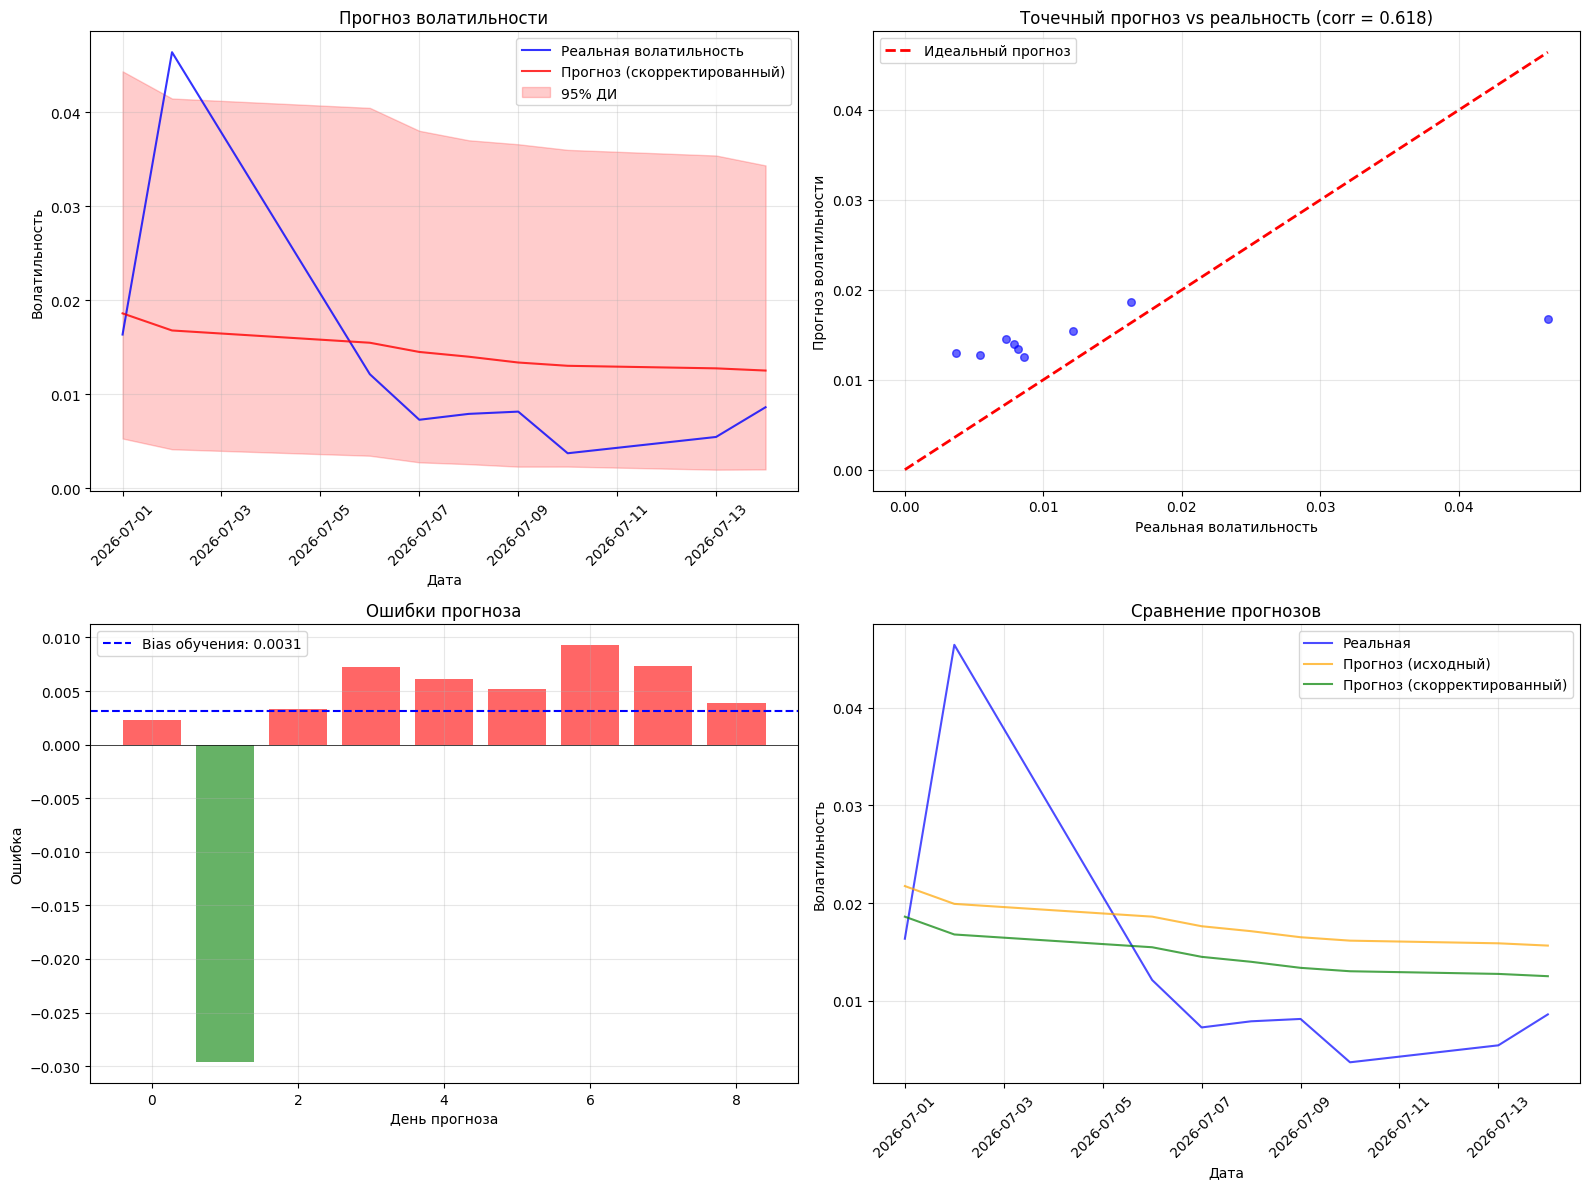

СТАТИСТИКА ПО ТЕСТОВОЙ ВЫБОРКЕ
Количество дней в тесте: 9
Средняя реальная волатильность: 0.012882
Стандартное отклонение: 0.012357
Максимальная волатильность: 0.046419
Минимальная волатильность: 0.003703


In [10]:
# Этап 5 : визуализация

if T_test > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))


    ax = axes[0, 0]
    dates_plot = df_forecast['date'].values
    ax.plot(dates_plot, vol_real_arr, 'b-', linewidth=1.5, alpha=0.8, label='Реальная волатильность')
    ax.plot(dates_plot, vol_mean_corrected, 'r-', linewidth=1.5, alpha=0.8, label='Прогноз (скорректированный)')
    ax.fill_between(dates_plot, vol_lower_corrected, vol_upper_corrected, color='red', alpha=0.2, label='95% ДИ')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Волатильность')
    ax.set_title(f'Прогноз волатильности')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)


    ax = axes[0, 1]
    ax.scatter(vol_real_arr, vol_mean_corrected, alpha=0.6, s=30, color='blue')
    max_val = max(vol_real_arr.max(), vol_mean_corrected.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Идеальный прогноз')
    ax.set_xlabel('Реальная волатильность')
    ax.set_ylabel('Прогноз волатильности')
    ax.set_title(f'Точечный прогноз vs реальность (corr = {corr:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)


    ax = axes[1, 0]
    error_plot = vol_mean_corrected - vol_real_arr
    colors = ['green' if e < 0 else 'red' for e in error_plot]
    ax.bar(range(len(error_plot)), error_plot, color=colors, alpha=0.6)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axhline(y=bias_train, color='blue', linestyle='--', label=f'Bias обучения: {bias_train:.4f}')
    ax.set_xlabel('День прогноза')
    ax.set_ylabel('Ошибка')
    ax.set_title('Ошибки прогноза')
    ax.legend()
    ax.grid(True, alpha=0.3)


    ax = axes[1, 1]
    ax.plot(dates_plot, vol_real_arr, 'b-', linewidth=1.5, alpha=0.7, label='Реальная')
    ax.plot(dates_plot, vol_mean_arr, 'orange', linewidth=1.5, alpha=0.7, label='Прогноз (исходный)')
    ax.plot(dates_plot, vol_mean_corrected, 'g-', linewidth=1.5, alpha=0.7, label='Прогноз (скорректированный)')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Волатильность')
    ax.set_title('Сравнение прогнозов')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


    print("СТАТИСТИКА ПО ТЕСТОВОЙ ВЫБОРКЕ")
    print(f"Количество дней в тесте: {len(df_forecast)}")
    print(f"Средняя реальная волатильность: {mean_real:.6f}")
    print(f"Стандартное отклонение: {float(np.std(vol_real_arr)):.6f}")
    print(f"Максимальная волатильность: {float(np.max(vol_real_arr)):.6f}")
    print(f"Минимальная волатильность: {float(np.min(vol_real_arr)):.6f}")



else:
    print("\nНет тестовых данных для визуализации!")